In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots render nicely inside Colab
%matplotlib inline
sns.set_theme(style="whitegrid")

print(f"Dataset Size: {df.shape[0]:,} Rows and {df.shape[1]} Columns")
print(f"Any missing values? {df.isnull().sum().sum()}")
df.head()

Dataset Size: 284,807 Rows and 31 Columns
Any missing values? 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Normal Transactions (Class 0): 284,315 (99.827%)
Fraud Transactions (Class 1): 492 (0.173%)


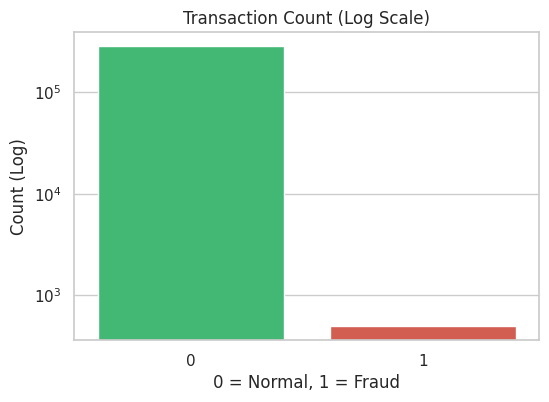

In [9]:
counts = df['Class'].value_counts()
percentages = df['Class'].value_counts(normalize=True) * 100

print(f"Normal Transactions (Class 0): {counts[0]:,} ({percentages[0]:.3f}%)")
print(f"Fraud Transactions (Class 1): {counts[1]:,} ({percentages[1]:.3f}%)")

# Plot Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.yscale('log') # Makes the rare fraud bar visible
plt.title('Transaction Count (Log Scale)')
plt.xlabel('0 = Normal, 1 = Fraud')
plt.ylabel('Count (Log)')
plt.show()

--- Normal Transaction Amounts ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraudulent Transaction Amounts ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


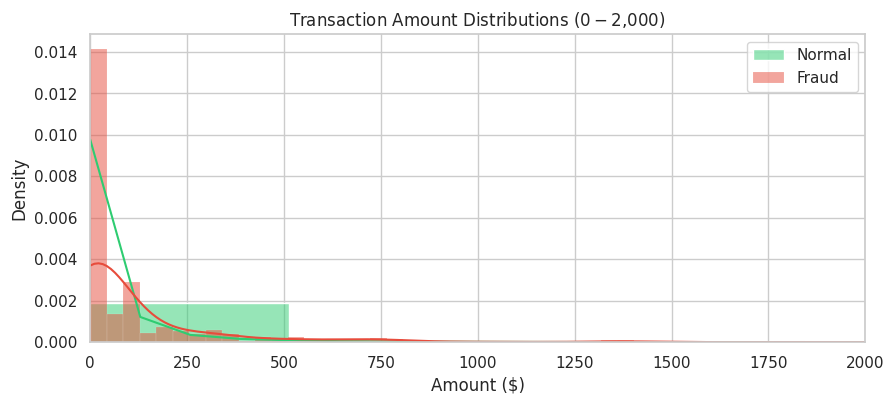

In [11]:
print("--- Normal Transaction Amounts ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Fraudulent Transaction Amounts ---")
print(df[df['Class'] == 1]['Amount'].describe())

# Plot distributions up to $2000 to keep it clean
plt.figure(figsize=(10, 4))
# Changed 'max_bins' to 'bins' here 👇
sns.histplot(df[df['Class'] == 0]['Amount'], color='#2ecc71', label='Normal', kde=True, stat="density", bins=50)
sns.histplot(df[df['Class'] == 1]['Amount'], color='#e74c3c', label='Fraud', kde=True, stat="density", bins=50)
plt.xlim([0, 2000])
plt.title('Transaction Amount Distributions ($0 - $2,000)')
plt.xlabel('Amount ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

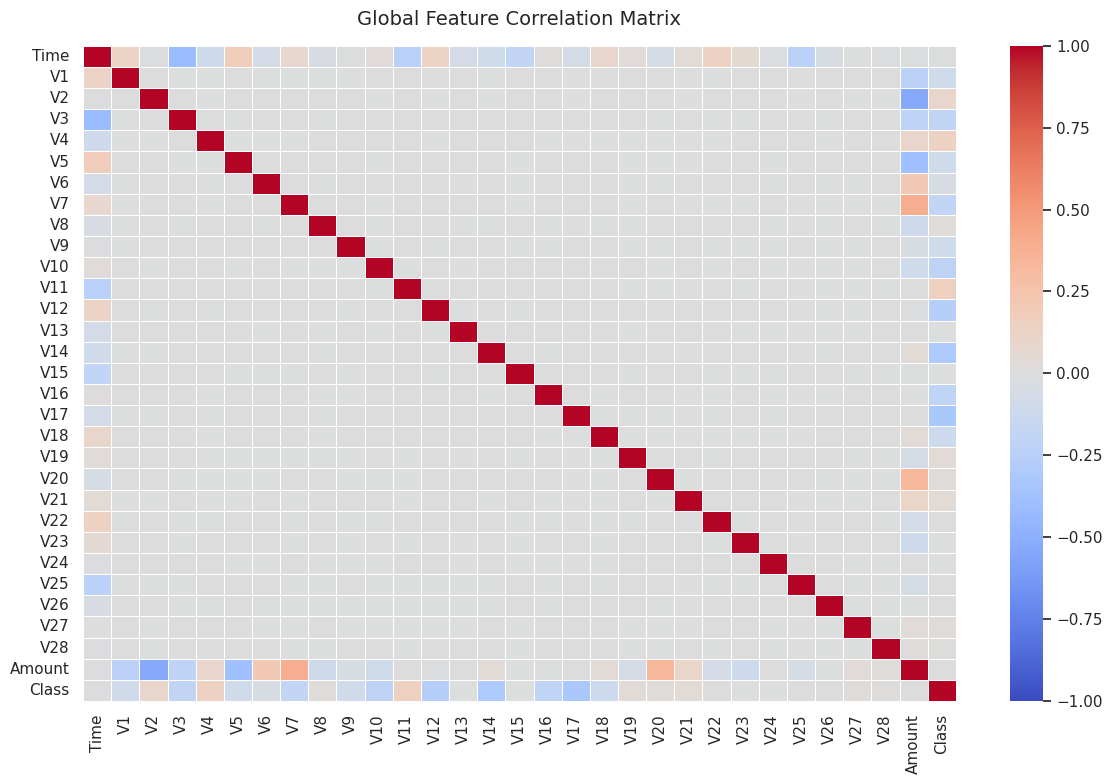

🔍 Look closely at the V1 to V28 blocks: They show absolute 0 correlation with one another.


In [ ]:
plt.figure(figsize=(12, 8))

# Compute the linear correlation matrix for all numerical columns
correlation_matrix = df.corr()

# Plot the heatmap using a diverging color palette (coolwarm)
sns.heatmap(correlation_matrix,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            linewidths=0.5)

plt.title('Global Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("Look closely at the V1 to V28 blocks: They show absolute 0 correlation with one another.")